In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d salader/dogsvscats


Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
License(s): unknown
 97% 1.03G/1.06G [00:11<00:00, 61.3MB/s]
100% 1.06G/1.06G [00:11<00:00, 97.6MB/s]


In [ ]:
import zipfile
import os

zip_path = "dogsvscats.zip"       # Kaggle se jo zip milega
extract_path = "dogs_vs_cats"     # naya folder jisme extract hoga

# Folder bana lo agar pehle se na ho
os.makedirs(extract_path, exist_ok=True)

# Extract karo
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset extracted to:", extract_path)


✅ Dataset extracted to: dogs_vs_cats


In [ ]:
# 1) Import libraries
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 2) Yahan augmentation add karo
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

# 3) Dataset load karo
train_generator = train_datagen.flow_from_directory(
    "dogs_vs_cats/train",
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary"
)

val_generator = test_datagen.flow_from_directory(
    "dogs_vs_cats/test",
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary"
)

# 4) Fir model.fit me use karo
# model.fit(
#     train_generator,
#     validation_data=val_generator,
#     epochs=20
# )

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten,BatchNormalization,Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# GENERATORS
# USED TO PROCESS LARGE AMOUNT OF DATA  MEANS CHOTY CHOTY BATCHES MAY DATA DETA HAI TAKY SYSTEM SLOW NA HO JATE

In [ ]:
# train_ds=keras.utils.image_dataset_from_directory(
#     directory = "dogs_vs_cats/train",
#     labels = "inferred",
#     label_mode = "int",
#     batch_size = 32,
#     image_size = (256,256)
# )
# test_ds=keras.utils.image_dataset_from_directory(
#     directory = "dogs_vs_cats/test",
#     labels = "inferred",
#     label_mode = "int",
#     batch_size = 32,
#     image_size = (256,256)
# )

In [ ]:
# Then we Normalized beacuse values of numpy array is 0-255, or hmay is ko 0-1 krna hai is range may

In [ ]:
# #Normalize
# def process(image,label):
#     image = tf.cast(image/255. ,tf.float32)
#     return image,label

# train_ds = train_ds.map(process)
# test_ds = test_ds.map(process)  # map function hr bar image train sy mikal kr function ko bhejy ga
# # or ya function transformation  kr ky hmay dy ga jis ko hm train or test may dubara save kr d gy


In [ ]:
# Create CNN model

model =Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(224,224,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=(2),padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=(2),padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=(2),padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,177,665 (42.64 MB)

 Trainable params: 11,177,473 (42.64 MB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0.00001,
    patience=2,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[callback]
)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 253s 405ms/step - accuracy: 0.8693 - loss: 0.3016 - val_accuracy: 0.8714 - val_loss: 0.3282
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 259s 401ms/step - accuracy: 0.8730 - loss: 0.3057 - val_accuracy: 0.7576 - val_loss: 1.4321
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 256s 410ms/step - accuracy: 0.8760 - loss: 0.2907 - val_accuracy: 0.8562 - val_loss: 0.3317
Epoch 3: early stopping


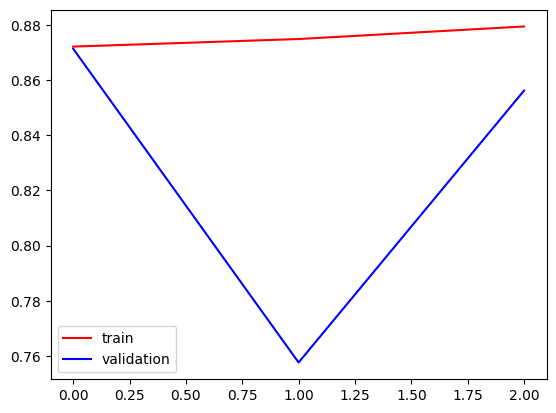

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

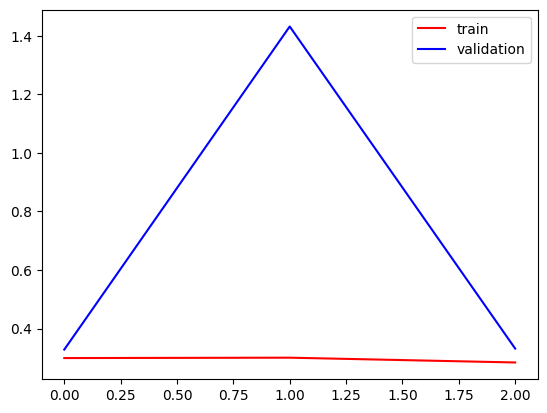

In [ ]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

In [ ]:
import cv2

In [ ]:
test_img =cv2.imread('Dog3.jpg')

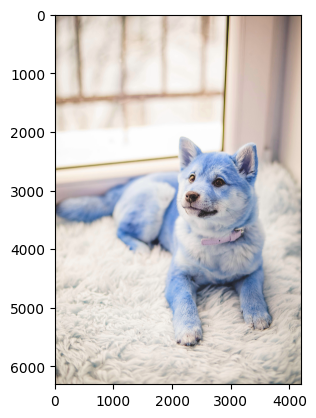

In [ ]:
plt.imshow(test_img)
plt.show()

In [ ]:
test_img.shape

(6306, 4204, 3)

In [ ]:
test_img=cv2.resize(test_img,(224,224))

In [ ]:
test_input=test_img.reshape((1,224,224,3))

In [ ]:
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


array([[1.]], dtype=float32)

In [ ]:
import cv2

In [ ]:
test_img =cv2.imread('Dog2.jpg')

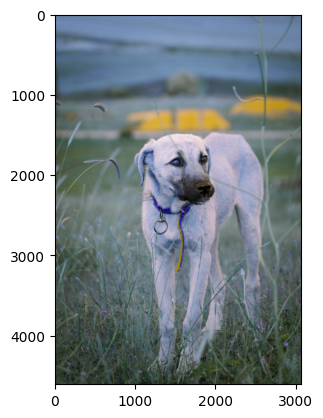

In [ ]:
plt.imshow(test_img)
plt.show()

In [ ]:
test_img.shape

(4608, 3072, 3)

In [ ]:
test_img=cv2.resize(test_img,(224,224))

In [ ]:
test_input=test_img.reshape((1,224,224,3))

In [ ]:
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


array([[1.]], dtype=float32)

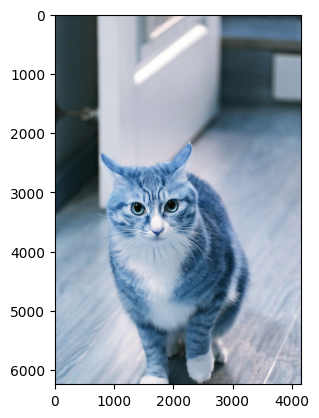

In [ ]:
import cv2
test_img =cv2.imread('MYcat.jpg')
plt.imshow(test_img)
plt.show()


In [ ]:
test_img.shape
test_img=cv2.resize(test_img,(224,224))
test_input=test_img.reshape((1,224,224,3))
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


array([[6.329729e-10]], dtype=float32)